In [9]:
import pandas as pd

# Load the dataset into a pandas DataFrame
df = pd.read_csv('/content/student_marks_prediction_dataset_1000.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Student_ID,Study_Hours,Attendance,Marks
0,S0001,5.3,51,74
1,S0002,2.3,58,50
2,S0003,5.6,84,85
3,S0004,4.9,52,67
4,S0005,1.2,64,50


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   1000 non-null   object 
 1   Study_Hours  1000 non-null   float64
 2   Attendance   1000 non-null   int64  
 3   Marks        1000 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 31.4+ KB


In [11]:
display(df.describe())

,Study_Hours,Attendance,Marks
count,1000.000000,1000.000000,1000.000000
mean,4.170300,76.131000,74.630000
std,2.146233,14.860238,17.164198
min,0.500000,50.000000,36.000000
25%,2.300000,64.000000,60.000000
50%,4.200000,77.000000,75.000000
75%,6.000000,89.000000,90.000000
max,8.000000,100.000000,100.000000


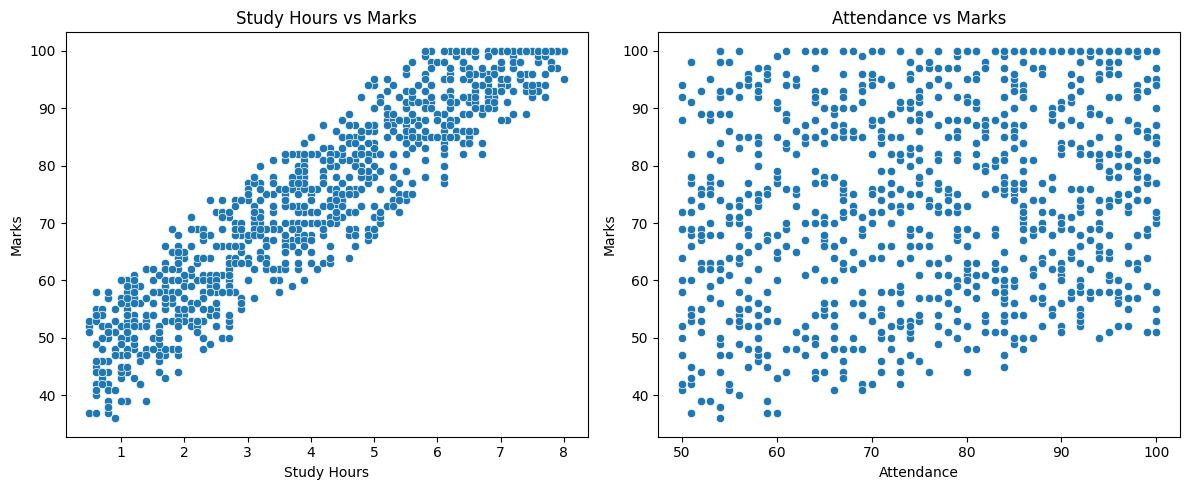

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots
plt.figure(figsize=(12, 5))

# Scatter plot for Study_Hours vs Marks
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x='Study_Hours', y='Marks', data=df)
plt.title('Study Hours vs Marks')
plt.xlabel('Study Hours')
plt.ylabel('Marks')

# Scatter plot for Attendance vs Marks
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x='Attendance', y='Marks', data=df)
plt.title('Attendance vs Marks')
plt.xlabel('Attendance')
plt.ylabel('Marks')

plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['Study_Hours', 'Attendance']]
y = df['Marks']

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 2)
X_test shape: (200, 2)
y_train shape: (800,)
y_test shape: (200,)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Evaluate the Linear Regression model
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")

Linear Regression Model Performance:
Mean Absolute Error (MAE): 2.79
Mean Squared Error (MSE): 10.76
Root Mean Squared Error (RMSE): 3.28
R-squared (R2): 0.97


In [15]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest Regressor model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")


Random Forest Regressor Model Performance:
Mean Absolute Error (MAE): 2.69
Mean Squared Error (MSE): 11.13
Root Mean Squared Error (RMSE): 3.34
R-squared (R2): 0.96


In [16]:
print("\n--- Model Comparison ---")
print("Linear Regression:")
print(f"  MAE: {mae_linear:.2f}")
print(f"  MSE: {mse_linear:.2f}")
print(f"  RMSE: {rmse_linear:.2f}")
print(f"  R2: {r2_linear:.2f}")

print("\nRandom Forest Regressor:")
print(f"  MAE: {mae_rf:.2f}")
print(f"  MSE: {mse_rf:.2f}")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  R2: {r2_rf:.2f}")

if r2_rf > r2_linear:
    print("\nThe Random Forest Regressor model performed better based on R-squared.")
elif r2_linear > r2_rf:
    print("\nThe Linear Regression model performed better based on R-squared.")
else:
    print("\nBoth models performed similarly based on R-squared.")


--- Model Comparison ---
Linear Regression:
  MAE: 2.79
  MSE: 10.76
  RMSE: 3.28
  R2: 0.97

Random Forest Regressor:
  MAE: 2.69
  MSE: 11.13
  RMSE: 3.34
  R2: 0.96

The Linear Regression model performed better based on R-squared.
